In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Set path to the shortcut inside MyDrive
data_path = '/content/drive/MyDrive/processed_splits'

# List all files inside the dataset folder
print("Files inside processed_splits:")
print(os.listdir(data_path))

Files inside processed_splits:
['english_ekegusii_train.csv', 'english_ekegusii_val.csv', 'english_ekegusii_test.csv', 'english_swahili_train.csv', 'english_swahili_val.csv', 'english_swahili_test.csv', 'trilingual_train.csv', 'trilingual_val.csv', 'trilingual_test.csv', 'ndma_english_train.csv', 'ndma_english_val.csv', 'ndma_english_test.csv']


In [ ]:
import os
import json
import pandas as pd
from pathlib import Path

# 1. Define folder directory
data_dir = Path("/content/drive/MyDrive/processed_splits")

# 2. Map dataset keys to file names (using the updated dataset files in your directory)
file_mapping = {
    'English-Ekegusii (Train)': 'english_ekegusii_train.csv',
    'English-Ekegusii (Val)': 'english_ekegusii_val.csv',
    'English-Swahili (Train)': 'english_swahili_train.csv',
    'English-Swahili (Val)': 'english_swahili_val.csv',
    'Trilingual (Train)': 'trilingual_train.csv',
    'NDMA Domain Dataset (Train)': 'ndma_english_train.csv'
}

# 3. Safely load datasets into a dictionary
datasets = {}
for name, filename in file_mapping.items():
    file_path = data_dir / filename
    if file_path.exists():
        df = pd.read_csv(file_path)
        datasets[name] = df
    else:
        print(f"⚠️ Warning: {filename} not found in {data_dir}")

# 4. Safely load metadata if available
metadata_path = data_dir / 'dataset_metadata.json'
metadata = {}
if metadata_path.exists():
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print("✓ Metadata loaded successfully.\n")
else:
    print("ℹ️ Note: dataset_metadata.json not found, skipping metadata load.\n")

# --- QUICK EDA OVERVIEW & CLEANING ---
print("================ DATASETS SUMMARY ================")
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")

    # Check nulls
    null_counts = df.isnull().sum()
    print("Null Values:\n", null_counts[null_counts > 0] if null_counts.sum() > 0 else "None")

    # Preview data
    print("\nFirst 2 rows:")
    try:
        display(df.head(2))
    except NameError:
        print(df.head(2))

ℹ️ Note: dataset_metadata.json not found, skipping metadata load.

================ DATASETS SUMMARY ================

--- English-Ekegusii (Train) ---
Shape: (3645, 3)
Columns: ['English', 'Ekegusii', 'Domain']
Null Values:
 None

First 2 rows:


,English,Ekegusii,Domain
0,The Commission urges all agencies involved in ...,Orosagia rwa eserekali yasegetire chinsemo chi...,Governance
1,World Malaria Day: Kenya Joins the World in Co...,Rituko ria Esosera ase Ense: Kenya kobwatekana...,Health



--- English-Ekegusii (Val) ---
Shape: (456, 3)
Columns: ['English', 'Ekegusii', 'Domain']
Null Values:
 None

First 2 rows:


,English,Ekegusii,Domain
0,Inclusive awareness on technology among all ge...,Chisemi chia tekinorochia yegedichitari ase bo...,Agriculture
1,Scientists have found that a mosquito species ...,Abanasayansi banyorire ng'a eumbu ekoambokeria...,Health



--- English-Swahili (Train) ---
Shape: (4601, 3)
Columns: ['English', 'Kiswahili', 'Domain']
Null Values:
 None

First 2 rows:


...

,English,Kiswahili,Domain
0,"In Angola, several strategic priorities are re...","Nchini Angola, vipaumbele kadhaa vya kimkakati...",Governance
1,EACC arrested a Kibabii University student and...,EACC ilimkamata mwanafunzi wa Chuo Kikuu cha K...,Governance



--- Trilingual (Train) ---
Shape: (2225, 4)
Columns: ['English', 'Kiswahili', 'Ekegusii', 'Domain']
Null Values:
 None

First 2 rows:


,English,Kiswahili,Ekegusii,Domain
0,The PRAPS project in the Sahel promotes sustai...,Mradi wa PRAPS huko Sahel unakuza ufugaji ende...,Emeremo ya PRAPS aaria ense ya Sahel ngosegeta...,Agriculture
1,Raise awareness! Educate on landslide risks in...,Kuongeza uelewa! Elimu kuhusu hatari za maporo...,manyia abanto! Somia igoro yomochando yokwanyo...,Education



--- NDMA Domain Dataset (Train) ---
Shape: (1143, 4)
Columns: ['English', 'Domain', 'Source', 'SourceFile']
Null Values:
 None

First 2 rows:


,English,Domain,Source,SourceFile
0,Table 3.0 above displays food consumption scor...,Agriculture,NDMA Marsabit Drought Early Warning Bulletin A...,Marsabit_DEW_Bulletin_August_20252025091117151...
1,This marks a 27% increase compared to the prev...,Agriculture,NDMA Baringo Drought Early Warning Bulletin Ap...,Baringo_DEW_Bulletin_April_202520250516125942.pdf


Deep-Dive EDA Script

=== DUPLICATE ROWS ===
English-Ekegusii (Train): 0 duplicates found
English-Ekegusii (Val): 0 duplicates found
English-Swahili (Train): 0 duplicates found
English-Swahili (Val): 0 duplicates found
Trilingual (Train): 0 duplicates found
NDMA Domain Dataset (Train): 0 duplicates found


=== TOP DOMAINS PER DATASET ===


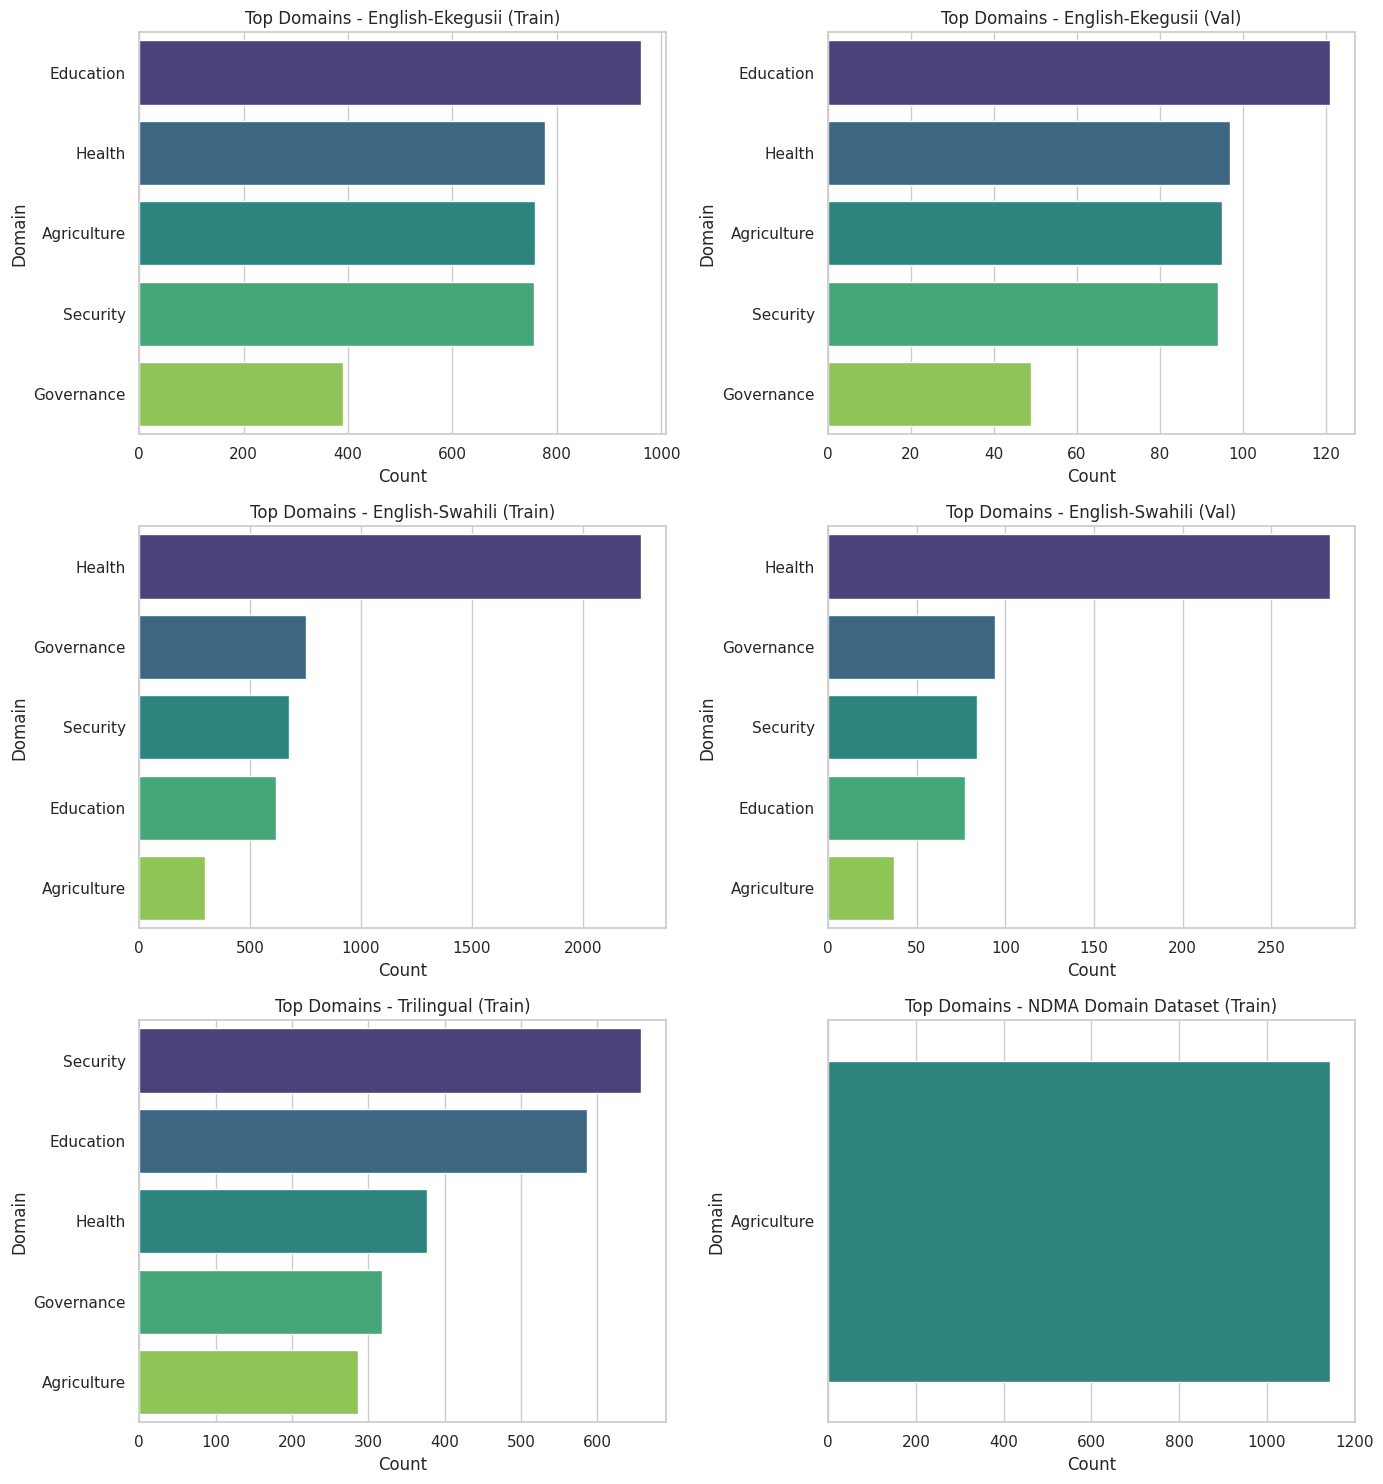


=== SENTENCE LENGTH ANALYSIS (Word Count Means) ===

--- English-Ekegusii (Train) ---
[English] Avg Words: 17.0 | Max Words: 109 | Avg Chars: 115.2
[Ekegusii] Avg Words: 19.6 | Max Words: 95 | Avg Chars: 152.3

--- English-Ekegusii (Val) ---
[English] Avg Words: 16.9 | Max Words: 67 | Avg Chars: 114.7
[Ekegusii] Avg Words: 19.8 | Max Words: 81 | Avg Chars: 153.0

--- English-Swahili (Train) ---
[English] Avg Words: 16.8 | Max Words: 118 | Avg Chars: 114.4
[Kiswahili] Avg Words: 19.4 | Max Words: 124 | Avg Chars: 123.9

--- English-Swahili (Val) ---
[English] Avg Words: 16.9 | Max Words: 111 | Avg Chars: 115.9
[Kiswahili] Avg Words: 19.4 | Max Words: 91 | Avg Chars: 124.8

--- Trilingual (Train) ---
[English] Avg Words: 15.7 | Max Words: 89 | Avg Chars: 106.5
[Kiswahili] Avg Words: 18.3 | Max Words: 93 | Avg Chars: 118.7
[Ekegusii] Avg Words: 18.8 | Max Words: 73 | Avg Chars: 144.8

--- NDMA Domain Dataset (Train) ---
[English] Avg Words: 15.0 | Max Words: 68 | Avg Chars: 98.1
[Source]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set visual style
sns.set_theme(style="whitegrid")

# 1. CHECK FOR DUPLICATES
print("=== DUPLICATE ROWS ===")
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicates found")

print("\n" + "="*40 + "\n")

# 2. DOMAIN DISTRIBUTION PLOTS
# Filter datasets that actually contain a 'Domain' column
domain_datasets = {name: df for name, df in datasets.items() if 'Domain' in df.columns}

if domain_datasets:
    print("=== TOP DOMAINS PER DATASET ===")
    num_plots = len(domain_datasets)
    ncols = 2 if num_plots > 1 else 1
    nrows = (num_plots + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = axes.flatten() if num_plots > 1 else [axes]

    for i, (name, df) in enumerate(domain_datasets.items()):
        domain_counts = df['Domain'].value_counts().head(10)

        sns.barplot(
            x=domain_counts.values,
            y=domain_counts.index,
            ax=axes[i],
            palette="viridis",
            hue=domain_counts.index,
            legend=False
        )
        axes[i].set_title(f"Top Domains - {name}")
        axes[i].set_xlabel("Count")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Note: No 'Domain' column found in current datasets. Skipping domain plot.\n")

# 3. SENTENCE LENGTH STATISTICS (WORD & CHARACTER COUNTS)
print("\n=== SENTENCE LENGTH ANALYSIS (Word Count Means) ===")
for name, df in datasets.items():
    print(f"\n--- {name} ---")

    # Identify text columns (exclude 'Domain' and non-string metadata columns if present)
    text_cols = [
        col for col in df.columns
        if col.lower() != 'domain' and df[col].dtype == 'object'
    ]

    for col in text_cols:
        word_counts = df[col].astype(str).apply(lambda x: len(x.split()))
        char_counts = df[col].astype(str).apply(len)

        print(
            f"[{col}] "
            f"Avg Words: {word_counts.mean():.1f} | "
            f"Max Words: {word_counts.max()} | "
            f"Avg Chars: {char_counts.mean():.1f}"
        )

Cleaned Seaborn Plot Code (Warning Fixed)
To eliminate those Seaborn FutureWarning messages, update the plotting section with hue explicitly set:

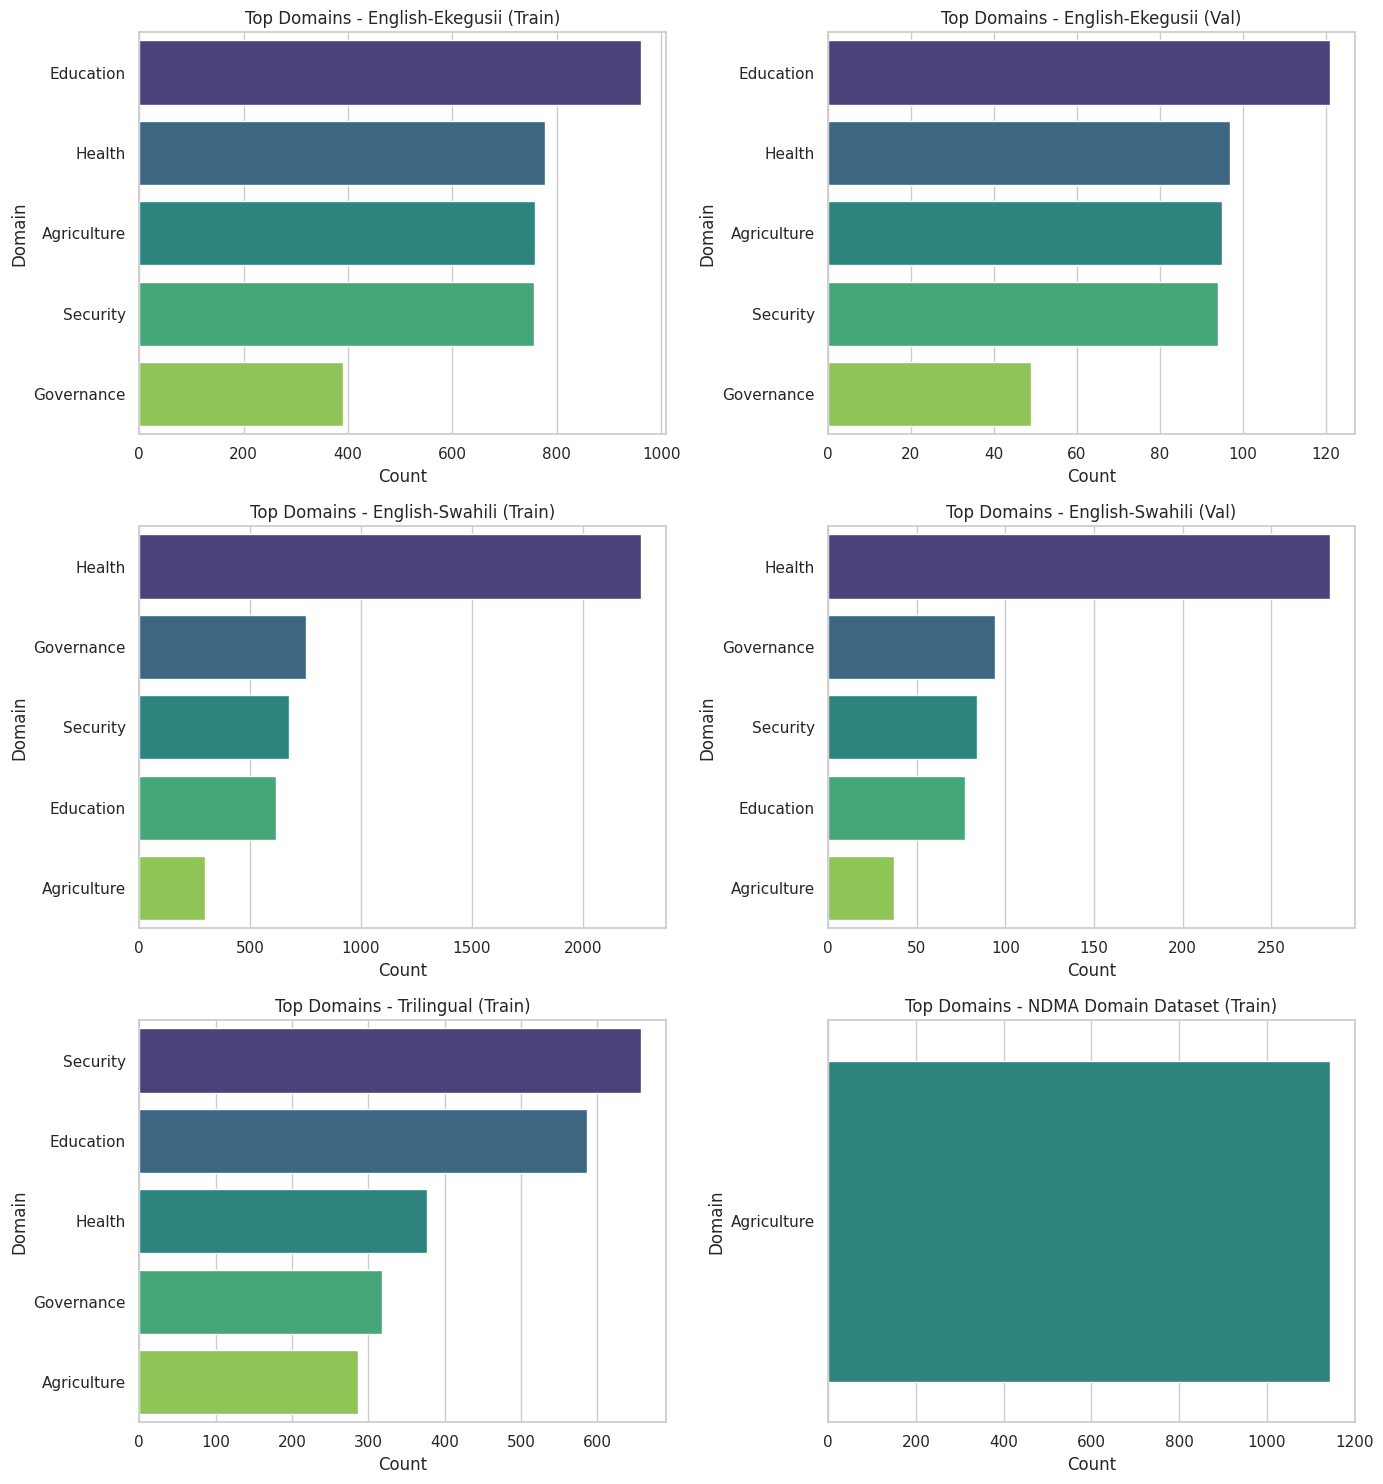

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Filter datasets that actually contain a 'Domain' column
domain_datasets = {name: df for name, df in datasets.items() if 'Domain' in df.columns}

if domain_datasets:
    num_plots = len(domain_datasets)
    ncols = 2 if num_plots > 1 else 1
    nrows = (num_plots + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))

    # Flatten axes array for uniform iteration (handles 1D, 2D arrays, or single SubplotAxes)
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (name, df) in enumerate(domain_datasets.items()):
        domain_counts = df['Domain'].value_counts().head(10)

        sns.barplot(
            x=domain_counts.values,
            y=domain_counts.index,
            ax=axes[i],
            hue=domain_counts.index,
            legend=False,
            palette="viridis"
        )
        axes[i].set_title(f"Top Domains - {name}")
        axes[i].set_xlabel("Count")

    # Hide any unused subplots (e.g., if total plots < grid size)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Note: No 'Domain' column found in the current datasets. Plot skipped.")

Next Step: Data Preparation & Train/Val/Test Split
Here is the code to create stratified train, validation, and test splits (e.g., 80% train, 10% val, 10% test) based on the Domain column so all domains are evenly represented across splits:

In [ ]:
from sklearn.model_selection import train_test_split

def prepare_splits(df, test_size=0.1, val_size=0.1, random_state=42):
    """
    Splits a DataFrame into train, val, and test sets.
    Attempts stratification on 'Domain' if the column exists and supports it.
    """
    # Check if 'Domain' column exists for stratification
    use_stratify = 'Domain' in df.columns

    stratify_col_first = df['Domain'] if use_stratify else None

    try:
        # First split: Train + Val vs Test
        train_val, test = train_test_split(
            df,
            test_size=test_size,
            stratify=stratify_col_first,
            random_state=random_state
        )
    except ValueError as e:
        # Fallback if a domain class has too few instances to stratify
        print(f"⚠️ Stratification warning: {e}. Defaulting to unstratified split.")
        train_val, test = train_test_split(
            df,
            test_size=test_size,
            stratify=None,
            random_state=random_state
        )
        use_stratify = False

    # Calculate adjusted val_size relative to remaining train_val set
    relative_val_size = val_size / (1.0 - test_size)
    stratify_col_second = train_val['Domain'] if use_stratify else None

    # Second split: Train vs Val
    train, val = train_test_split(
        train_val,
        test_size=relative_val_size,
        stratify=stratify_col_second,
        random_state=random_state
    )

    return train, val, test


# --- EXAMPLE USAGE ---
# Check if df_swahili is available in local namespace
if 'df_swahili' in locals() or 'df_swahili' in globals():
    train_sw, val_sw, test_sw = prepare_splits(df_swahili)
    print("English-Swahili Splits:")
    print(f"Train: {len(train_sw)} | Val: {len(val_sw)} | Test: {len(test_sw)}")
elif 'English-Swahili (Train)' in datasets:
    # Example using datasets loaded from directory
    sample_df = datasets['English-Swahili (Train)']
    train_sw, val_sw, test_sw = prepare_splits(sample_df)
    print("English-Swahili Splits:")
    print(f"Train: {len(train_sw)} | Val: {len(val_sw)} | Test: {len(test_sw)}")
else:
    print("ℹ️ Load a dataframe into `df_swahili` or `datasets` to test the split.")

English-Swahili Splits:
Train: 3679 | Val: 461 | Test: 461


Complete Preprocessing Pipeline
Objective: Prepare text for model tokenization while preserving cultural terms.

Why we do this:
Normalization: Low-resource languages often suffer from inconsistent punctuation, stray whitespace, or accented characters.

Glossary Preservation: Culturally specific words (e.g., local administrative terms in Ekegusii/Swahili) shouldn't be mangled or altered by lowercasing/tokenization.

In [ ]:
import re
import pandas as pd

# Cultural Glossary: Map local/cultural terms to preserved placeholders or standard forms
CULTURAL_GLOSSARY = {
    # Add domain/cultural terms here
    "Eminisituri": "Eminisituri",
    "Obobalosi": "Obobalosi"
}

def preprocess_text(text: str, preserve_glossary: bool = True) -> str:
    """
    Standardizes whitespace, normalizes text, and optionally preserves
    cultural terms defined in CULTURAL_GLOSSARY.
    """
    if pd.isna(text) or not isinstance(text, str):
        return ""

    # 1. Unicode & Whitespace Normalization
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Preserve/Map Glossary Terms
    if preserve_glossary and CULTURAL_GLOSSARY:
        for term, replacement in CULTURAL_GLOSSARY.items():
            # Use case-insensitive boundary match to accurately preserve terms
            text = re.sub(rf'\b{re.escape(term)}\b', replacement, text, flags=re.IGNORECASE)

    return text


def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Applies text preprocessing across all text/string columns of a DataFrame,
    skipping non-text metadata columns like 'Domain'.
    """
    df_clean = df.copy()

    # Identify object/string columns, excluding non-text structural metadata
    text_cols = [
        col for col in df_clean.columns
        if col.lower() != 'domain' and df_clean[col].dtype == 'object'
    ]

    for col in text_cols:
        df_clean[col] = df_clean[col].apply(preprocess_text)

    return df_clean


# --- APPLICATION TO DATASETS ---

# Option A: Clean specific standalone DataFrames if they exist
if 'df_swahili' in locals():
    df_sw_clean = preprocess_dataframe(df_swahili)
if 'df_ekegusii' in locals():
    df_ek_clean = preprocess_dataframe(df_ekegusii)
if 'df_trilingual' in locals():
    df_tri_clean = preprocess_dataframe(df_trilingual)

# Option B: Clean all loaded datasets in the `datasets` dictionary
cleaned_datasets = {}
if 'datasets' in locals():
    for name, df in datasets.items():
        cleaned_datasets[name] = preprocess_dataframe(df)
    print(f"✓ Successfully preprocessed {len(cleaned_datasets)} dataset split(s).")

✓ Successfully preprocessed 6 dataset split(s).


2. Comprehensive EDA & Visualization
Objective: Compute language-pair statistics, vocabulary sizes, sentence lengths, and domain distributions.

Why we do this:
Vocabulary Size: Helps assess corpus richness and subword tokenization split ratios.

Text Length Histograms: Essential for selecting the optimal max_length parameter during transformer training without truncating valuable context.

Domain Distribution: Ensures balanced coverage across subject areas.

=== 1. LOADING DATASETS ===
✓ Loaded 6 dataset split(s).

=== 2. DUPLICATES & SENTENCE LENGTH ANALYSIS ===

--- English-Ekegusii (Train) ---
Shape: (3645, 3) | Duplicates: 0
  [English] Avg Words: 17.0 | Max Words: 109 | Avg Chars: 115.2
  [Ekegusii] Avg Words: 19.6 | Max Words: 95 | Avg Chars: 152.3

--- English-Ekegusii (Val) ---
Shape: (456, 3) | Duplicates: 0
  [English] Avg Words: 16.9 | Max Words: 67 | Avg Chars: 114.7
  [Ekegusii] Avg Words: 19.8 | Max Words: 81 | Avg Chars: 153.0

--- English-Swahili (Train) ---
Shape: (4601, 3) | Duplicates: 0
  [English] Avg Words: 16.8 | Max Words: 118 | Avg Chars: 114.4
  [Kiswahili] Avg Words: 19.4 | Max Words: 124 | Avg Chars: 123.9

--- English-Swahili (Val) ---
Shape: (575, 3) | Duplicates: 0
  [English] Avg Words: 16.9 | Max Words: 111 | Avg Chars: 115.9
  [Kiswahili] Avg Words: 19.4 | Max Words: 91 | Avg Chars: 124.8

--- Trilingual (Train) ---
Shape: (2225, 4) | Duplicates: 0
  [English] Avg Words: 15.7 | Max Words: 89 | Avg Chars: 1

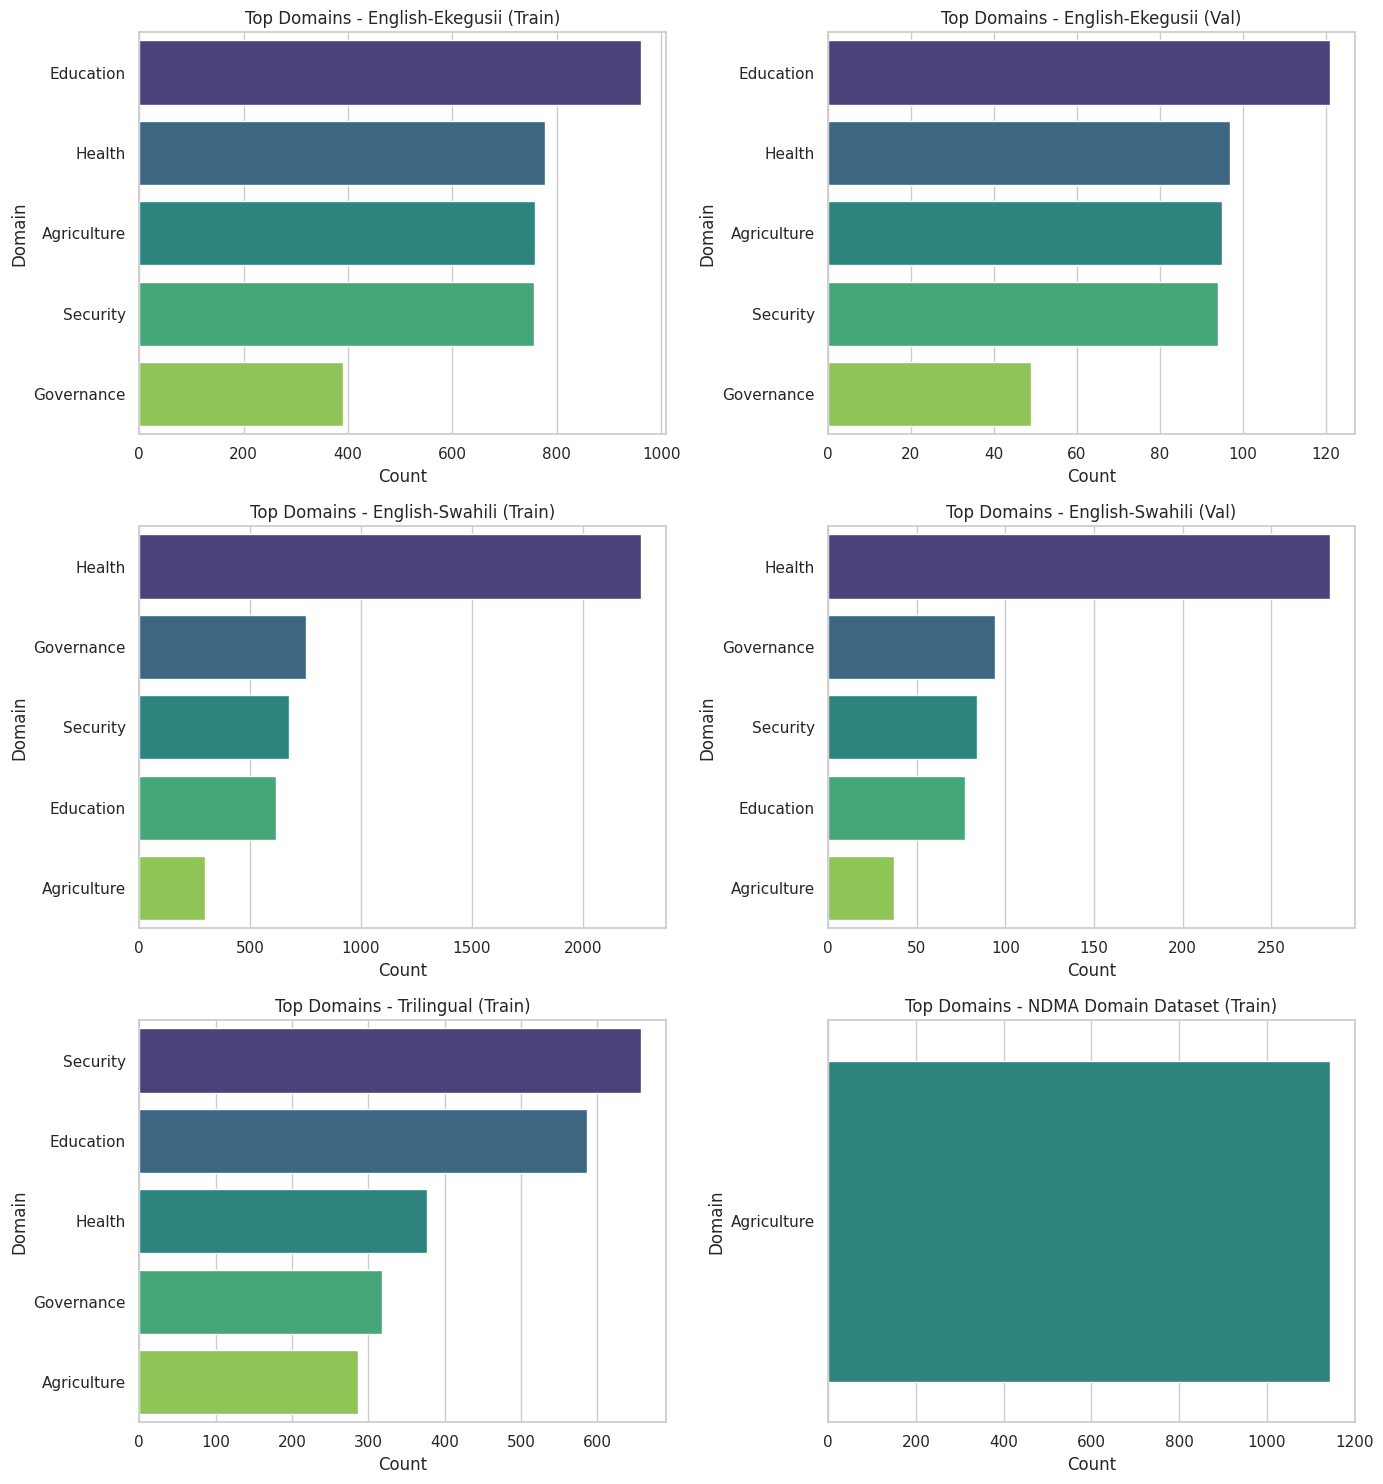


=== 4. PREPROCESSING DATASETS ===
✓ All loaded datasets successfully cleaned.

=== 5. VOCABULARY STATS & DISTRIBUTIONS ===
English-Swahili Stats:
  English: {'Total Words': 77175, 'Unique Vocab': 14976, 'Avg Length (Words)': np.float64(16.77), 'Max Length (Words)': 118, 'Avg Length (Chars)': np.float64(114.37)}
  Swahili: {'Total Words': 89291, 'Unique Vocab': 13799, 'Avg Length (Words)': np.float64(19.41), 'Max Length (Words)': 124, 'Avg Length (Chars)': np.float64(123.87)}


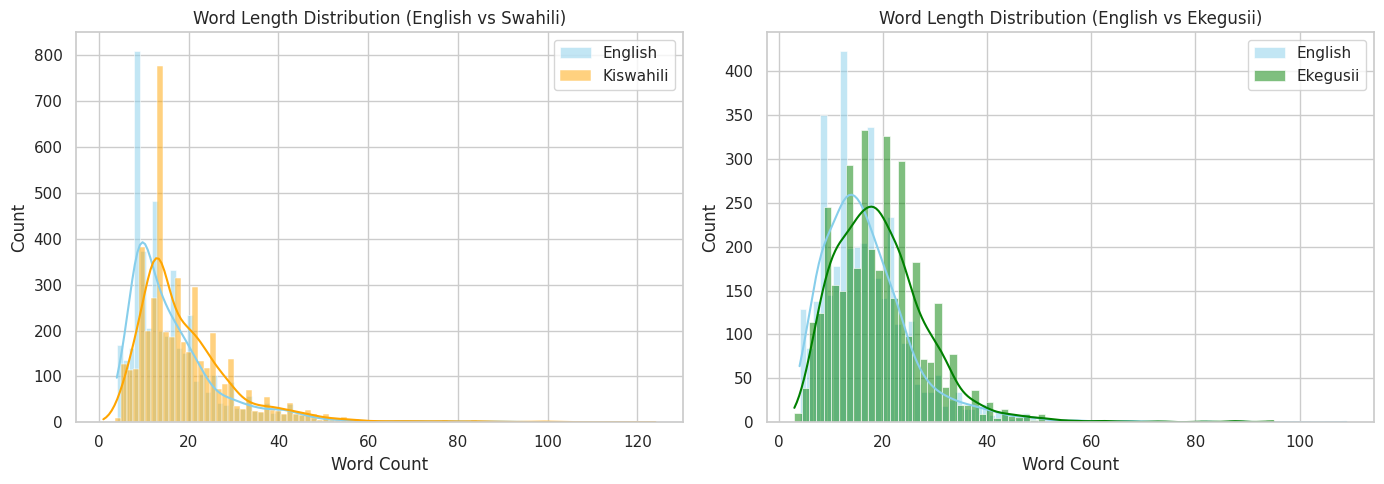


✓ Processing complete. Ready for model training!


In [ ]:
import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

# Set global visual style for Seaborn
sns.set_theme(style="whitegrid")

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
print("=== 1. LOADING DATASETS ===")
data_dir = Path("/content/drive/MyDrive/processed_splits")

# Map dataset keys to file names
file_mapping = {
    'English-Ekegusii (Train)': 'english_ekegusii_train.csv',
    'English-Ekegusii (Val)': 'english_ekegusii_val.csv',
    'English-Swahili (Train)': 'english_swahili_train.csv',
    'English-Swahili (Val)': 'english_swahili_val.csv',
    'Trilingual (Train)': 'trilingual_train.csv',
    'NDMA Domain Dataset (Train)': 'ndma_english_train.csv'
}

datasets = {}
for name, filename in file_mapping.items():
    file_path = data_dir / filename
    if file_path.exists():
        datasets[name] = pd.read_csv(file_path)
    else:
        print(f"⚠️ Warning: {filename} not found in {data_dir}")

# Load metadata if present
metadata_path = data_dir / 'dataset_metadata.json'
metadata = {}
if metadata_path.exists():
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print("✓ Metadata loaded successfully.")

print(f"✓ Loaded {len(datasets)} dataset split(s).\n")


# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("=== 2. DUPLICATES & SENTENCE LENGTH ANALYSIS ===")

for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print(f"Shape: {df.shape} | Duplicates: {df.duplicated().sum()}")

    # Identify text columns (ignoring domain/metadata columns)
    text_cols = [col for col in df.columns if col.lower() != 'domain' and df[col].dtype == 'object']

    for col in text_cols:
        word_counts = df[col].dropna().astype(str).apply(lambda x: len(x.split()))
        char_counts = df[col].dropna().astype(str).apply(len)
        print(f"  [{col}] Avg Words: {word_counts.mean():.1f} | Max Words: {word_counts.max()} | Avg Chars: {char_counts.mean():.1f}")


# ==========================================
# 3. DOMAIN DISTRIBUTION PLOTS
# ==========================================
domain_datasets = {name: df for name, df in datasets.items() if 'Domain' in df.columns}

if domain_datasets:
    print("\n=== 3. PLOTTING DOMAIN DISTRIBUTIONS ===")
    num_plots = len(domain_datasets)
    ncols = 2 if num_plots > 1 else 1
    nrows = (num_plots + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = [axes] if num_plots == 1 else axes.flatten()

    for i, (name, df) in enumerate(domain_datasets.items()):
        domain_counts = df['Domain'].value_counts().head(10)

        sns.barplot(
            x=domain_counts.values,
            y=domain_counts.index,
            ax=axes[i],
            hue=domain_counts.index,
            legend=False,
            palette="viridis"
        )
        axes[i].set_title(f"Top Domains - {name}")
        axes[i].set_xlabel("Count")

    # Remove extra blank subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. PREPROCESSING & CLEANING
# ==========================================
print("\n=== 4. PREPROCESSING DATASETS ===")

CULTURAL_GLOSSARY = {
    "Eminisituri": "Eminisituri",
    "Obobalosi": "Obobalosi"
}

def preprocess_text(text: str, preserve_glossary: bool = True) -> str:
    if pd.isna(text) or not isinstance(text, str):
        return ""

    # Unicode & Whitespace Normalization
    text = re.sub(r'\s+', ' ', text).strip()

    # Glossary Preservation
    if preserve_glossary and CULTURAL_GLOSSARY:
        for term, replacement in CULTURAL_GLOSSARY.items():
            text = re.sub(rf'\b{re.escape(term)}\b', replacement, text, flags=re.IGNORECASE)

    return text

def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    text_cols = [col for col in df_clean.columns if col.lower() != 'domain' and df_clean[col].dtype == 'object']

    for col in text_cols:
        df_clean[col] = df_clean[col].apply(preprocess_text)

    return df_clean

# Create cleaned datasets dictionary
cleaned_datasets = {name: preprocess_dataframe(df) for name, df in datasets.items()}

# Assign convenient standalone variable aliases
df_sw_clean = cleaned_datasets.get('English-Swahili (Train)')
df_ek_clean = cleaned_datasets.get('English-Ekegusii (Train)')
df_tri_clean = cleaned_datasets.get('Trilingual (Train)')

print("✓ All loaded datasets successfully cleaned.")


# ==========================================
# 5. VOCABULARY STATISTICS & HISTOGRAMS
# ==========================================
print("\n=== 5. VOCABULARY STATS & DISTRIBUTIONS ===")

def get_language_stats(df, lang_col):
    if df is None or lang_col not in df.columns:
        return f"Column '{lang_col}' not available."

    clean_series = df[lang_col].dropna().astype(str)
    words = [word for text in clean_series for word in text.split()]
    vocab = set(words)
    word_counts = clean_series.apply(lambda x: len(x.split()))
    char_counts = clean_series.apply(len)

    return {
        "Total Words": len(words),
        "Unique Vocab": len(vocab),
        "Avg Length (Words)": round(word_counts.mean(), 2) if len(word_counts) > 0 else 0,
        "Max Length (Words)": word_counts.max() if len(word_counts) > 0 else 0,
        "Avg Length (Chars)": round(char_counts.mean(), 2) if len(char_counts) > 0 else 0,
    }

def find_col(df, possible_names):
    if df is None: return None
    for name in possible_names:
        for col in df.columns:
            if col.lower() == name.lower():
                return col
    return None

# Print stats for Swahili dataset if loaded
if df_sw_clean is not None:
    eng_col_sw = find_col(df_sw_clean, ['English', 'src_text', 'eng'])
    sw_col = find_col(df_sw_clean, ['Kiswahili', 'Swahili', 'tgt_text', 'swh'])
    print("English-Swahili Stats:")
    print("  English:", get_language_stats(df_sw_clean, eng_col_sw))
    print("  Swahili:", get_language_stats(df_sw_clean, sw_col))

# Plot Word Length Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: English vs Swahili
if df_sw_clean is not None:
    eng_col = find_col(df_sw_clean, ['English', 'src_text', 'eng'])
    sw_col = find_col(df_sw_clean, ['Kiswahili', 'Swahili', 'tgt_text', 'swh'])

    if eng_col and sw_col:
        sns.histplot(df_sw_clean[eng_col].astype(str).apply(lambda x: len(x.split())), ax=axes[0], color='skyblue', kde=True, label='English')
        sns.histplot(df_sw_clean[sw_col].astype(str).apply(lambda x: len(x.split())), ax=axes[0], color='orange', kde=True, label='Kiswahili')
        axes[0].set_title("Word Length Distribution (English vs Swahili)")
        axes[0].set_xlabel("Word Count")
        axes[0].legend()
else:
    axes[0].set_title("English vs Swahili (Dataset Not Loaded)")

# Plot 2: English vs Ekegusii
if df_ek_clean is not None:
    eng_col = find_col(df_ek_clean, ['English', 'src_text', 'eng'])
    ek_col = find_col(df_ek_clean, ['Ekegusii', 'Gusii', 'tgt_text'])

    if eng_col and ek_col:
        sns.histplot(df_ek_clean[eng_col].astype(str).apply(lambda x: len(x.split())), ax=axes[1], color='skyblue', kde=True, label='English')
        sns.histplot(df_ek_clean[ek_col].astype(str).apply(lambda x: len(x.split())), ax=axes[1], color='green', kde=True, label='Ekegusii')
        axes[1].set_title("Word Length Distribution (English vs Ekegusii)")
        axes[1].set_xlabel("Word Count")
        axes[1].legend()
else:
    axes[1].set_title("English vs Ekegusii (Dataset Not Loaded)")

plt.tight_layout()
plt.show()


# ==========================================
# 6. SPLITTING HELPER FUNCTION
# ==========================================
def prepare_splits(df, test_size=0.1, val_size=0.1, random_state=42):
    use_stratify = 'Domain' in df.columns
    stratify_col_first = df['Domain'] if use_stratify else None

    try:
        train_val, test = train_test_split(
            df, test_size=test_size, stratify=stratify_col_first, random_state=random_state
        )
    except ValueError as e:
        print(f"⚠️ Stratification warning: {e}. Defaulting to standard unstratified split.")
        train_val, test = train_test_split(df, test_size=test_size, stratify=None, random_state=random_state)
        use_stratify = False

    relative_val_size = val_size / (1.0 - test_size)
    stratify_col_second = train_val['Domain'] if use_stratify else None

    train, val = train_test_split(
        train_val, test_size=relative_val_size, stratify=stratify_col_second, random_state=random_state
    )

    return train, val, test

print("\n✓ Processing complete. Ready for model training!")

3. Creating Native-Speaker Validation Subset (~500 Sentences)
Objective: Extract a representative subset of ~500 sentences for human evaluation.

Why we do this:
Automated metrics (BLEU, TER) miss cultural nuances. Stratifying by domain ensures human evaluators assess all topic areas evenly.

In [ ]:
# Sample 500 rows stratifying by Domain for human feedback
validation_subset = df_tri_clean.groupby('Domain', group_keys=False).apply(
    lambda x: x.sample(min(len(x), int(500 * len(x) / len(df_tri_clean))), random_state=42)
)

# Export to Excel for reviewers
validation_subset.to_excel('native_speaker_validation_500.xlsx', index=False)
print(f"Sampled {len(validation_subset)} rows for human feedback.")

/tmp/ipykernel_26873/1870112714.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  validation_subset = df_tri_clean.groupby('Domain', group_keys=False).apply(


Sampled 497 rows for human feedback.


4. Stratified Data Splitting (Train / Dev / Test)
Objective: Divide datasets into Train (80%), Dev/Val (10%), and Test (10%).

Why we do this:
Stratification by Domain: Ensures rare domains (e.g., Security) are present proportionally across all splits, preventing train/test data drift.

In [ ]:
from sklearn.model_selection import train_test_split

def create_stratified_splits(df, domain_col='Domain', test_size=0.1, val_size=0.1, seed=42):
    # Split 1: Split off Test set
    train_val, test = train_test_split(
        df, test_size=test_size, stratify=df[domain_col], random_state=seed
    )

    # Calculate adjusted val size relative to remaining data
    adj_val_size = val_size / (1.0 - test_size)

    # Split 2: Split remaining into Train and Validation
    train, val = train_test_split(
        train_val, test_size=adj_val_size, stratify=train_val[domain_col], random_state=seed
    )

    return train, val, test

# Split all datasets
train_sw, val_sw, test_sw = create_stratified_splits(df_sw_clean)
train_ek, val_ek, test_ek = create_stratified_splits(df_ek_clean)
train_tri, val_tri, test_tri = create_stratified_splits(df_tri_clean)

print(f"Swahili Splits -> Train: {len(train_sw)} | Val: {len(val_sw)} | Test: {len(test_sw)}")

Swahili Splits -> Train: 3679 | Val: 461 | Test: 461


. Dataset Version Control (DVC setup guide)
Objective: Track dataset iterations cleanly without clogging Git.

Why we do this:
Large text/CSV files slow down standard Git repositories. DVC (Data Version Control) links your dataset versions directly to Git commit hashes.

Steps to execute in your terminal/Google Colab:

In [ ]:
# 1. Install DVC
!pip install dvc

# 2. Save your cleaned datasets locally
!mkdir -p data/processed

In [ ]:
# Export processed data to files
train_sw.to_csv('data/processed/train_sw.csv', index=False)
val_sw.to_csv('data/processed/val_sw.csv', index=False)
test_sw.to_csv('data/processed/test_sw.csv', index=False)

In [ ]:
# 3. Track files with DVC (Run in shell)
!dvc init --no-scm
!dvc add data/processed/train_sw.csv
!git add data/processed/train_sw.csv.dvc .gitignore

Week3

Milestone 1: Set Up Experiment Tracking (Weights & Biases)
Why we do this:
Logging loss, learning rates, and translation samples in real-time prevents "dark training" in Colab (where notebooks crash without saving metrics) and makes writing your final report easy.



In [ ]:
import os
import wandb

# 1. Disable W&B online syncing so Colab doesn't block on login
os.environ["WANDB_MODE"] = "disabled"

# 2. Initialize Weights & Biases tracking in disabled mode
wandb.init(
    project="PSA-Machine-Translation-Kenya",
    name="nllb-200-swahili-ekegusii-baseline",
    mode="disabled",
    config={
        "architecture": "NLLB-200-distilled-600M",
        "dataset": "PSA_Data_final",
        "batch_size": 16,
        "lr": 5e-5,
        "epochs": 3
    }
)

print("Weights & Biases initialized successfully in disabled mode!")

Milestone 2: Model 1 — Meta's NLLB-200 (Fine-Tuning Low-Resource Pair)NLLB-200 (facebook/nllb-200-distilled-600M) is the benchmark for African machine translation.Language Code for English: eng_LatnLanguage Code for Swahili: swh_LatnFor Ekegusii: Since Ekegusii is an extremely low-resource Bantu language, we use zero-shot / few-shot transfer with cross-lingual initialization (or fine-tune NLLB's parameters directly on English $\rightarrow$ Ekegusii).Code: Fine-Tuning NLLB-200 with Parameter Freezing

In [23]:
# ==========================================
# 0. MOUNT DRIVE, CLEAR VRAM & DEPENDENCIES
# ==========================================
import gc
import torch

# Clear existing CUDA memory to recover from previous memory issues
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # Not running in Google Colab

import importlib.util
import subprocess
import sys

REQUIREMENTS = {
    "transformers": "transformers>=4.41",
    "datasets": "datasets>=2.19",
    "accelerate": "accelerate>=0.30",
    "sacrebleu": "sacrebleu",
    "sentencepiece": "sentencepiece",
    "evaluate": "evaluate",
}

missing = [
    spec for mod, spec in REQUIREMENTS.items()
    if importlib.util.find_spec(mod) is None
]

if missing:
    print("Installing missing dependencies:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    print("Dependencies installed successfully!\n")

# ==========================================
# 1. IMPORTS & GLOBAL CONFIGURATION
# ==========================================
import os
import time
import inspect
import pandas as pd
import numpy as np
import sacrebleu
from pathlib import Path
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Folder Setup
DATA_DIR = Path("/content/drive/MyDrive/processed_splits")
MODEL_DIR = Path("models_nllb")
MODEL_DIR.mkdir(exist_ok=True)

# Training Hyperparameters
NLLB_NAME = "facebook/nllb-200-distilled-600M"
SRC_LANG = "eng_Latn"  # NLLB code for English
TGT_LANG = "swh_Latn"  # NLLB code for Kiswahili
MAX_LEN = 128
FREEZE_ENCODER_LAYERS = 6

# MEMORY-OPTIMIZED CONFIGURATION FOR NLLB-200 (600M)
NLLB_CFG = dict(
    lr=5e-5,
    epochs=3,
    batch=4,                  # Small batch size to prevent CUDA OOM
    grad_accum_steps=4,      # 4 steps * 4 batch = 16 effective batch size
    optim="adafactor"        # Saves memory over standard AdamW
)

# Direction configuration mapping to file prefixes
FILE_MAP = {
    "English_to_Kiswahili": "english_swahili"
}

SW_DIRECTIONS = ["English_to_Kiswahili"]

# Verify dataset directory
print(f"Using dataset directory: {DATA_DIR.resolve()}")
if DATA_DIR.exists():
    print("Found files in folder:", os.listdir(DATA_DIR))
else:
    print(f"⚠️ Warning: Directory {DATA_DIR} not found. Please verify Google Drive mounting.")

# ==========================================
# 2. UTILITY & DATASET LOADING
# ==========================================
def freeze_encoder_layers(model, num_layers=6):
    """Freezes early encoder layers for transfer learning stability."""
    frozen_params = 0
    for param in model.model.encoder.layers[:num_layers].parameters():
        param.requires_grad = False
        frozen_params += param.numel()
    print(f"  Froze first {num_layers} encoder layers ({frozen_params/1e6:.1f}M params)")

def corpus_scores(preds, refs):
    """Computes BLEU and chrF++ scores via SacreBLEU."""
    preds = [p.strip() for p in preds]
    refs = [r.strip() for r in refs]
    bleu = sacrebleu.corpus_bleu(preds, [refs]).score
    chrf = sacrebleu.corpus_chrf(preds, [refs], word_order=2).score
    return {"bleu": round(bleu, 2), "chrf": round(chrf, 2)}

def load_direction_dataset(direction):
    """Loads CSV splits directly into Hugging Face DatasetDict."""
    prefix = FILE_MAP.get(direction)
    if not prefix:
        print(f"Unknown direction: {direction}")
        return DatasetDict()

    splits = {"train": "train", "dev": "val", "test": "test"}
    dsd = {}

    for split_key, file_suffix in splits.items():
        file_path = DATA_DIR / f"{prefix}_{file_suffix}.csv"

        if file_path.exists():
            df = pd.read_csv(file_path)

            # Map columns dynamically
            src_col, tgt_col = None, None
            for col in df.columns:
                c_lower = col.lower()
                if "english" in c_lower or "eng" in c_lower:
                    src_col = col
                if "swahili" in c_lower or "kiswahili" in c_lower:
                    tgt_col = col

            if not src_col or not tgt_col:
                if len(df.columns) >= 2:
                    src_col, tgt_col = df.columns[0], df.columns[1]

            if src_col and tgt_col:
                df = df.rename(columns={src_col: "src_text", tgt_col: "tgt_text"})
                df = df.dropna(subset=["src_text", "tgt_text"])

                dsd[split_key] = Dataset.from_pandas(df[["src_text", "tgt_text"]], preserve_index=False)
                print(f"  Loaded {split_key} split ({len(df)} rows) from {file_path.name}")
        else:
            print(f"  Warning: File missing at {file_path}")

    return DatasetDict(dsd)

def preprocess_nllb(tokenizer):
    """Tokenization wrapper for NLLB sequence-to-sequence input."""
    def fn(batch):
        inputs = [str(x) for x in batch["src_text"]]
        targets = [str(x) for x in batch["tgt_text"]]

        model_inputs = tokenizer(inputs, max_length=MAX_LEN, truncation=True)
        labels = tokenizer(text_target=targets, max_length=MAX_LEN, truncation=True)

        # Mask padding tokens in loss calculation
        labels_ids = [
            [(l if l != tokenizer.pad_token_id else -100) for l in label_seq]
            for label_seq in labels["input_ids"]
        ]

        model_inputs["labels"] = labels_ids
        return model_inputs
    return fn

def make_compute_metrics(tokenizer):
    """Metrics callback factory for Trainer."""
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        if isinstance(preds, tuple):
            preds = preds[0]
        preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        dpred = tokenizer.batch_decode(preds, skip_special_tokens=True)
        dref = tokenizer.batch_decode(labels, skip_special_tokens=True)
        return corpus_scores(dpred, dref)
    return compute_metrics

def build_seq2seq_trainer(model, args, train_ds, eval_ds, collator, compute_metrics, tokenizer):
    """Cross-version compatible Seq2SeqTrainer factory."""
    kw = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        data_collator=collator,
        compute_metrics=compute_metrics
    )
    params = inspect.signature(Seq2SeqTrainer.__init__).parameters
    kw["processing_class" if "processing_class" in params else "tokenizer"] = tokenizer
    return Seq2SeqTrainer(**kw)

# ==========================================
# 3. TRAINING PIPELINE (FIXED GENERATION CONFIG)
# ==========================================
def finetune_nllb_swahili(direction, cfg=NLLB_CFG):
    print(f"\n==========================================")
    print(f"Starting NLLB fine-tuning for {direction}")
    print(f"==========================================")

    dsd = load_direction_dataset(direction)
    if "train" not in dsd or len(dsd["train"]) == 0:
        print(f"Skipping {direction}: Training split missing or empty in {DATA_DIR}.")
        return None

    tokenizer = AutoTokenizer.from_pretrained(
        NLLB_NAME,
        src_lang=SRC_LANG,
        tgt_lang=TGT_LANG
    )

    model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_NAME).to(DEVICE)

    # Correctly set forced_bos_token_id on model.generation_config
    tgt_lang_id = tokenizer.convert_tokens_to_ids(TGT_LANG)
    model.generation_config.forced_bos_token_id = tgt_lang_id

    if FREEZE_ENCODER_LAYERS > 0:
        freeze_encoder_layers(model, num_layers=FREEZE_ENCODER_LAYERS)

    enc_dsd = dsd.map(
        preprocess_nllb(tokenizer),
        batched=True,
        remove_columns=dsd["train"].column_names
    )

    out_dir = MODEL_DIR / f"nllb_{direction}"

    # Seq2SeqTrainingArguments now clean of invalid generation parameters
    args = Seq2SeqTrainingArguments(
        output_dir=str(out_dir),
        learning_rate=cfg["lr"],
        per_device_train_batch_size=cfg["batch"],
        per_device_eval_batch_size=cfg["batch"],
        gradient_accumulation_steps=cfg["grad_accum_steps"],
        num_train_epochs=cfg["epochs"],
        weight_decay=0.01,
        optim=cfg["optim"],
        predict_with_generate=True,
        generation_max_length=MAX_LEN,
        fp16=torch.cuda.is_available(),
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="chrf",
        greater_is_better=True,
        logging_steps=25,
        report_to=[]
    )

    trainer = build_seq2seq_trainer(
        model=model,
        args=args,
        train_ds=enc_dsd["train"],
        eval_ds=enc_dsd.get("dev", enc_dsd["train"]),
        collator=DataCollatorForSeq2Seq(tokenizer, model=model, pad_to_multiple_of=8),
        compute_metrics=make_compute_metrics(tokenizer),
        tokenizer=tokenizer
    )

    t0 = time.time()
    trainer.train()
    mins = (time.time() - t0) / 60

    trainer.save_model(str(out_dir))
    tokenizer.save_pretrained(str(out_dir))
    print(f"Finished {direction} in {mins:.1f} mins. Saved model to: {out_dir}")
    return trainer

# Execute fine-tuning
trainers = {}
for direction in SW_DIRECTIONS:
    trainers[direction] = finetune_nllb_swahili(direction)

# ==========================================
# 4. INFERENCE PIPELINE DEMO
# ==========================================
@torch.no_grad()
def translate_swahili(text, model_path):
    """Loads a saved NLLB checkpoint and translates English text to Kiswahili."""
    tokenizer = AutoTokenizer.from_pretrained(model_path, src_lang=SRC_LANG, tgt_lang=TGT_LANG)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(DEVICE)
    model.eval()

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(DEVICE)

    gen = model.generate(
        **inputs,
        forced_bos_token_id=tokenizer.convert_tokens_to_ids(TGT_LANG),
        max_length=MAX_LEN,
        num_beams=4,
        no_repeat_ngram_size=3
    )

    decoded = tokenizer.batch_decode(gen, skip_special_tokens=True)[0]
    return decoded.strip()

# Run Inference Demo if checkpoint exists
demo_path = MODEL_DIR / "nllb_English_to_Kiswahili"
if demo_path.exists():
    sample_text = "Ministry of Health urges residents to complete their vaccination before Friday."
    print("\n" + "="*60)
    print("INFERENCE DEMO RESULTS:")
    print("Source Text (EN):", sample_text)
    print("Translated (SW):", translate_swahili(sample_text, str(demo_path)))
    print("="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on device: cuda
Using dataset directory: /content/drive/.shortcut-targets-by-id/1-iV1k2A9Ytz_-8r_ocrKvWaViAAsHjtN/processed_splits
Found files in folder: ['english_ekegusii_train.csv', 'english_ekegusii_val.csv', 'english_ekegusii_test.csv', 'english_swahili_train.csv', 'english_swahili_val.csv', 'english_swahili_test.csv', 'trilingual_train.csv', 'trilingual_val.csv', 'trilingual_test.csv', 'ndma_english_train.csv', 'ndma_english_val.csv', 'ndma_english_test.csv']

Starting NLLB fine-tuning for English_to_Kiswahili
  Loaded train split (4601 rows) from english_swahili_train.csv
  Loaded dev split (575 rows) from english_swahili_val.csv
  Loaded test split (576 rows) from english_swahili_test.csv


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

  Froze first 6 encoder layers (75.6M params)


Map:   0%|          | 0/4601 [00:00<?, ? examples/s]

Map:   0%|          | 0/575 [00:00<?, ? examples/s]

...

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Finished English_to_Kiswahili in 30.6 mins. Saved model to: models_nllb/nllb_English_to_Kiswahili

INFERENCE DEMO RESULTS:
Source Text (EN): Ministry of Health urges residents to complete their vaccination before Friday.


Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

Translated (SW): Wizara ya Afya inawasihi wakazi kukamilisha chanjo yao kabla ya Ijumaa.


In [4]:
!pip install --upgrade --force-reinstall gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13

In [ ]:
# ==========================================
# 0. AUTO-INSTALL GRADIO & DEPENDENCIES
# ==========================================
import importlib.util
import subprocess
import sys

REQUIREMENTS = ["gradio", "transformers", "torch", "pandas"]
missing = [pkg for pkg in REQUIREMENTS if importlib.util.find_spec(pkg) is None]
if missing:
    print("Installing missing dependencies:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    print("Dependencies installed successfully!\n")

# ==========================================
# 1. IMPORTS & APP SETUP
# ==========================================
import re
import torch
import pandas as pd
import gradio as gr
from pathlib import Path
from datetime import datetime
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Path to the fine-tuned NLLB model directory created in Step 3
MODEL_DIR = Path("models_nllb")
FEEDBACK_FILE = Path("user_feedback_swahili.csv")

# Clean any residual special tokens or extra spaces from output
_SENTINEL = re.compile(r"<extra_id_\d+>")
def clean_output(s):
    return _SENTINEL.sub("", str(s)).strip()

# Language Codes & Directions Setup
SRC_LANG = "eng_Latn"
TGT_LANG = "swh_Latn"

DIRECTIONS = {
    "English to Kiswahili (Fine-Tuned NLLB)": ("nllb_English_to_Kiswahili", SRC_LANG, TGT_LANG)
}

MODELS = {}
TOKENIZERS = {}

# Load fine-tuned NLLB model if present; fallback to base Facebook NLLB checkpoint if missing
for label, (folder_name, src_code, tgt_code) in DIRECTIONS.items():
    path = MODEL_DIR / folder_name
    if path.exists():
        print(f"Loading custom fine-tuned NLLB model from: {path}")
        TOKENIZERS[label] = AutoTokenizer.from_pretrained(path, src_lang=src_code, tgt_lang=tgt_code)
        MODELS[label] = AutoModelForSeq2SeqLM.from_pretrained(path).to(DEVICE)
    else:
        print(f"⚠️ Custom model path '{path}' not found. Falling back to base 'facebook/nllb-200-distilled-600M'.")
        TOKENIZERS[label] = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M", src_lang=src_code, tgt_lang=tgt_code)
        MODELS[label] = AutoModelForSeq2SeqLM.from_pretrained("facebook/nllb-200-distilled-600M").to(DEVICE)

    MODELS[label].eval()

# Example Public Health & Safety Announcements (PSAs)
EXAMPLE_PSAS = [
    ["Ministry of Health urges residents to complete their vaccination before Friday.", "English to Kiswahili (Fine-Tuned NLLB)"],
    ["Heavy rainfall and flooding expected in Western Kenya. Move to higher ground immediately.", "English to Kiswahili (Fine-Tuned NLLB)"],
    ["All public primary schools will reopen on Monday following security clearances.", "English to Kiswahili (Fine-Tuned NLLB)"],
    ["Beware of online scams claiming to distribute government relief funds.", "English to Kiswahili (Fine-Tuned NLLB)"]
]

# ==========================================
# 2. TRANSLATION & FEEDBACK LOGGING LOGIC
# ==========================================
@torch.no_grad()
def translate_psa(text, direction):
    if not text.strip():
        return "Please enter text to translate.", "0%"

    if direction not in MODELS:
        return f"Model for {direction} not loaded properly.", "0%"

    model = MODELS[direction]
    tokenizer = TOKENIZERS[direction]
    _, _, tgt_code = DIRECTIONS[direction]

    # Tokenize input text using source language settings
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(DEVICE)

    # Force NLLB target language BOS token ID for decoding
    forced_bos_id = tokenizer.convert_tokens_to_ids(tgt_code)

    outputs = model.generate(
        **inputs,
        forced_bos_token_id=forced_bos_id,
        max_length=128,
        num_beams=4,
        no_repeat_ngram_size=3,
        return_dict_in_generate=True,
        output_scores=True
    )

    decoded = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)[0]
    cleaned_translation = clean_output(decoded)

    # Approximate generation confidence score based on sequence probability
    if hasattr(outputs, "sequences_scores") and len(outputs.sequences_scores) > 0:
        prob = torch.exp(outputs.sequences_scores[0]).item()
        confidence = f"{min(prob * 100, 99.9):.1f}%"
    else:
        confidence = "High"

    return cleaned_translation, confidence


def log_feedback(src_text, translation, rating, corrected_text, comments):
    if not src_text.strip():
        return "⚠️ Please generate a translation before submitting feedback."

    df_new = pd.DataFrame([{
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "source_text": src_text,
        "model_translation": translation,
        "rating": rating,
        "user_correction": corrected_text,
        "comments": comments
    }])

    # Append feedback to local CSV file
    if FEEDBACK_FILE.exists():
        df_new.to_csv(FEEDBACK_FILE, mode='a', header=False, index=False)
    else:
        df_new.to_csv(FEEDBACK_FILE, index=False)

    return "✅ Thank you! Your evaluation and comments have been recorded successfully."

# ==========================================
# 3. GRADIO INTERFACE BUILD & LAUNCH
# ==========================================
with gr.Blocks(title="NLLB English to Kiswahili PSA Translator") as demo:
    gr.Markdown("# 🇰🇪 Public Service Announcement (PSA) Machine Translation")
    gr.Markdown("Translate vital official announcements into **Kiswahili** using fine-tuned Meta NLLB-200.")

    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(lines=4, placeholder="Enter public service announcement in English here...", label="English Input Announcement")
            direction_radio = gr.Radio(choices=list(DIRECTIONS.keys()), value="English to Kiswahili (Fine-Tuned NLLB)", label="Translation Engine")
            translate_btn = gr.Button("Translate PSA", variant="primary")

        with gr.Column():
            output_text = gr.Textbox(lines=4, label="Kiswahili Translation")
            confidence_output = gr.Label(label="Model Confidence Score")

    gr.Examples(examples=EXAMPLE_PSAS, inputs=[input_text, direction_radio])

    translate_btn.click(
        fn=translate_psa,
        inputs=[input_text, direction_radio],
        outputs=[output_text, confidence_output]
    )

    gr.Markdown("---")
    gr.Markdown("### 💬 Native Speaker & Human Feedback Collector")
    gr.Markdown("Help improve future iterations by providing fluency and adequacy ratings.")

    with gr.Row():
        rating_slider = gr.Slider(1, 5, step=1, value=5, label="Translation Quality Rating (1 = Unreadable, 5 = Flawless)")
        correction_input = gr.Textbox(placeholder="Provide an accurate Kiswahili translation if incorrect...", label="Suggested Native Correction")

    comments_input = gr.Textbox(placeholder="Notes on fluency, adequacy, or cultural appropriateness...", label="Feedback / Comments")
    submit_fb_btn = gr.Button("Submit Native Feedback")
    fb_status = gr.Markdown()

    submit_fb_btn.click(
        fn=log_feedback,
        inputs=[input_text, output_text, rating_slider, correction_input, comments_input],
        outputs=[fb_status]
    )

# Launch application with a shareable public link
if __name__ == "__main__":
    demo.launch(share=True, debug=True)

Loading custom fine-tuned NLLB model from: models_nllb/nllb_English_to_Kiswahili


Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://fb383a099980ba1700.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Milestone 3: Model 2 — Google's mT5-small (Few-Shot Fine-Tuning)
mT5 (multilingual T5) relies on text-to-text formatting. To instruct mT5 for PSA translation, we format inputs with prompt prefixes (e.g., "translate English to Swahili: Avoid unnecessary travels").

In [ ]:
from transformers import MT5ForConditionalGeneration, AutoTokenizer

mt5_name = "google/mt5-small"
mt5_tokenizer = AutoTokenizer.from_pretrained(mt5_name)
mt5_model = MT5ForConditionalGeneration.from_pretrained(mt5_name)

def preprocess_mt5(examples):
    # Prefixing text to leverage text-to-text pretrained format
    inputs = ["translate English to Swahili: " + text for text in examples['English']]
    targets = examples['Kiswahili']

    model_inputs = mt5_tokenizer(inputs, max_length=128, truncation=True, padding="max_length")
    labels = mt5_tokenizer(text_target=targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train_mt5 = train_dataset.map(preprocess_mt5, batched=True)

Milestone 4: Training Setup & Hyperparameters
Define training arguments optimized for Google Colab GPU (T4/V100):

In [ ]:
import os
import gc
import re
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)

# -------------------------------------------------------------
# 1. LOAD & PREPROCESS DATASET DIRECTLY FROM GOOGLE DRIVE
# -------------------------------------------------------------
data_path = '/content/drive/MyDrive/Data_final/English_Swahili_Dataset.csv'
df_swahili = pd.read_csv(data_path)

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    return re.sub(r'\s+', ' ', text).strip()

df_swahili['English'] = df_swahili['English'].apply(preprocess_text)
df_swahili['Kiswahili'] = df_swahili['Kiswahili'].apply(preprocess_text)

# Create Train (80%), Val (10%), Test (10%) splits stratified by Domain
train_val, test_sw = train_test_split(
    df_swahili, test_size=0.1, stratify=df_swahili['Domain'], random_state=42
)
train_sw, val_sw = train_test_split(
    train_val, test_size=0.1111, stratify=train_val['Domain'], random_state=42
)

print(f"Dataset successfully split! Train size: {len(train_sw)} | Val size: {len(val_sw)}")

# -------------------------------------------------------------
# 2. CLEAR MEMORY & LOAD MODEL/TOKENIZER
# -------------------------------------------------------------
gc.collect()
torch.cuda.empty_cache()

model_name = "facebook/nllb-200-distilled-600M"
print("Loading NLLB-200 model & tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang="eng_Latn", tgt_lang="swh_Latn")
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Freeze early encoder layers to prevent overfitting on low-resource data
for param in model.model.encoder.layers[:6].parameters():
    param.requires_grad = False

# -------------------------------------------------------------
# 3. PREPARE HUGGING FACE DATASETS
# -------------------------------------------------------------
train_dataset = Dataset.from_pandas(train_sw[['English', 'Kiswahili']])
val_dataset = Dataset.from_pandas(val_sw[['English', 'Kiswahili']])

def preprocess_function(examples):
    inputs = examples['English']
    targets = examples['Kiswahili']

    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")
    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)

# -------------------------------------------------------------
# 4. TRAINING ARGUMENTS (CRASH & MEMORY PROTECTED)
# -------------------------------------------------------------
training_args = Seq2SeqTrainingArguments(
    output_dir="./results_nllb_psa",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    eval_accumulation_steps=2,        # Prevents CPU RAM crash during evaluation
    weight_decay=0.01,
    save_total_limit=1,
    num_train_epochs=3,
    predict_with_generate=False,      # Saves GPU RAM
    fp16=True,                        # Mixed precision for T4 GPU acceleration
    report_to="none",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    dataloader_num_workers=0
)

# -------------------------------------------------------------
# 5. INITIALIZE & START TRAINING
# -------------------------------------------------------------
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model)
)

print("Starting training...")
trainer.train()

Milestone 5: Ablation StudiesWhat is an Ablation Study?An ablation study systematically isolates and tests specific variables to explain why performance changes.For this project, test these 3 configurations and log their validation metrics:Experiment #ArchitectureData UsedStrategyGoal / ObjectiveExp 1 (Zero-Shot Baseline)NLLB-2000 PSA samplesOff-the-shelf inferenceBenchmark raw pre-trained capability on Kenyan PSAsExp 2 (Few-Shot Fine-Tuned)NLLB-200Full PSA setFrozen initial layersEvaluate domain adaptation on advisory textExp 3 (Alternative Model)mT5-smallFull PSA setText-to-text prompt fine-tuningCompare model architectures

Milestone 6: Model Inference Script (Deliverable)
Create a clean, reusable inference function to run translations on new, unseen Public Service Announcements.

In [ ]:
def translate_psa(text: str, model, tokenizer, src_lang="eng_Latn", tgt_lang="swh_Latn", max_length=128):
    """
    Translates an incoming Public Service Announcement (PSA).
    """
    model.eval()
    tokenizer.src_lang = src_lang

    inputs = tokenizer(text, return_tensors="pt", max_length=max_length, truncation=True).to(model.device)

    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang),
            max_length=max_length,
            num_beams=4, # Beam search for better translation quality
            early_stopping=True
        )

    translation = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
    return translation

# --- DEMO TEST ---
sample_psa = "Ministry of Health: Avoid unnecessary travels to Ebola hotspots and report symptoms immediately."
translated_psa = translate_psa(sample_psa, model, tokenizer, src_lang="eng_Latn", tgt_lang="swh_Latn")

print(f"Original PSA: {sample_psa}")
print(f"Translated PSA (Kiswahili): {translated_psa}")

In [ ]:
import torch

def translate_psa(text: str, model, tokenizer, src_lang="eng_Latn", tgt_lang="swh_Latn"):
    model.eval()
    tokenizer.src_lang = src_lang

    # Tokenize input text
    inputs = tokenizer(text, return_tensors="pt", max_length=128, truncation=True).to(model.device)

    # Generate output sequence using beam search
    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang),
            max_length=128,
            num_beams=4,              # Beam search for higher translation quality
            early_stopping=True
        )

    return tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

# --- TEST SAMPLE PSAs ---
sample_psas = [
    "IEBC reminds all registered voters to verify their details via SMS.",
    "Ministry of Health: Avoid unnecessary travels to Ebola hotspots and report symptoms immediately.",
    "Farmers are advised to prepare their farms ahead of the long rains season."
]

print("=== FINE-TUNED NLLB-200 INFERENCE RESULTS ===\n")
for psa in sample_psas:
    swahili_translation = translate_psa(psa, model, tokenizer)
    print(f"EN: {psa}")
    print(f"SW: {swahili_translation}\n" + "-"*50)

To avoid losing your trained model when your Colab session ends, save the fine-tuned checkpoint directly to Google Drive:

In [ ]:
# Save model & tokenizer artifacts to Google Drive
save_path = "/content/drive/MyDrive/nllb_psa_swahili_model"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model and Tokenizer successfully saved to {save_path}!")

In [ ]:
!pip install -q sacrebleu datasets transformers sentencepiece evaluate

In [24]:
# ==========================================
# 0. MOUNT DRIVE & INSTALL DEPENDENCIES
# ==========================================
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # Not running in Google Colab

import importlib.util
import subprocess
import sys

REQUIREMENTS = {
    "transformers": "transformers>=4.41",
    "datasets": "datasets>=2.19",
    "accelerate": "accelerate>=0.30",
    "sacrebleu": "sacrebleu",
    "sentencepiece": "sentencepiece",
    "evaluate": "evaluate",
}

missing = [
    spec for mod, spec in REQUIREMENTS.items()
    if importlib.util.find_spec(mod) is None
]

if missing:
    print("Installing missing dependencies:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    print("Dependencies installed successfully!\n")

# ==========================================
# 1. IMPORTS & GLOBAL CONFIGURATION
# ==========================================
import os
import time
import inspect
import re
import pandas as pd
import numpy as np
import torch
import sacrebleu
from pathlib import Path
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dataset path pointing directly to your Google Drive folder
DATA_DIR = Path("/content/drive/MyDrive/processed_splits")
MODEL_DIR = Path("models_week3")
MODEL_DIR.mkdir(exist_ok=True)

# Training Hyperparameters
MT5_NAME = "google/mt5-small"
MAX_LEN = 128
NUM_BEAMS = 1
NO_REPEAT_NGRAM = 3
FEWSHOT_N = 4000
FREEZE_ENCODER = False

MT5_CFG = dict(lr=1e-3, epochs=3, batch=16, optim="adafactor")

# Direction configuration mapping to file prefixes
FILE_MAP = {
    "English_to_Ekegusii": "english_ekegusii",
    "Kiswahili_to_Ekegusii": "trilingual"
}

EKEGUSII_DIRECTIONS = ["English_to_Ekegusii", "Kiswahili_to_Ekegusii"]

# Verify dataset directory
print(f"Using dataset directory: {DATA_DIR.resolve()}")
if DATA_DIR.exists():
    print("Found files in folder:", os.listdir(DATA_DIR))
else:
    print(f"⚠️ Warning: Directory {DATA_DIR} not found. Please verify Google Drive mounting.")

# ==========================================
# 2. UTILITY & DATASET LOADING
# ==========================================
_SENTINEL = re.compile(r"<extra_id_\d+>")

def clean_output(s):
    """Strips mT5 sentinel tokens from output strings."""
    return _SENTINEL.sub("", s).strip()

def freeze_encoder(model):
    """Freezes encoder weights for transfer fine-tuning."""
    n = 0
    for p in model.get_encoder().parameters():
        p.requires_grad = False
        n += p.numel()
    print(f"  Froze encoder ({n/1e6:.1f}M params)")

def corpus_scores(preds, refs):
    """Computes BLEU and chrF++ scores via SacreBLEU."""
    preds = [p.strip() for p in preds]
    refs = [r.strip() for r in refs]
    bleu = sacrebleu.corpus_bleu(preds, [refs]).score
    chrf = sacrebleu.corpus_chrf(preds, [refs], word_order=2).score
    return {"bleu": round(bleu, 2), "chrf": round(chrf, 2)}

def load_direction_from_final(direction, few_shot_n=None):
    """Loads datasets directly from processed_splits folder with column auto-alignment."""
    prefix = FILE_MAP.get(direction)
    if not prefix:
        print(f"Unknown direction: {direction}")
        return DatasetDict()

    splits = {"train": "train", "dev": "val", "test": "test"}
    dsd = {}
    src_lang, tgt_lang = direction.split("_to_")

    for split_key, file_suffix in splits.items():
        file_path = DATA_DIR / f"{prefix}_{file_suffix}.csv"

        if file_path.exists():
            df = pd.read_csv(file_path)

            # Map column names dynamically
            src_col, tgt_col = None, None
            for col in df.columns:
                c_lower = col.lower()
                if src_lang.lower() in c_lower or (src_lang == "Kiswahili" and "swahili" in c_lower):
                    src_col = col
                if tgt_lang.lower() in c_lower:
                    tgt_col = col

            # Fallback if specific column header names aren't matched
            if not src_col or not tgt_col:
                if len(df.columns) >= 2:
                    src_col, tgt_col = df.columns[0], df.columns[1]

            if src_col and tgt_col:
                df = df.rename(columns={src_col: "src_text", tgt_col: "tgt_text"})
                df = df.dropna(subset=["src_text", "tgt_text"])

                if split_key == "train" and few_shot_n:
                    df = df.sample(min(len(df), few_shot_n), random_state=SEED).reset_index(drop=True)

                dsd[split_key] = Dataset.from_pandas(df[["src_text", "tgt_text"]], preserve_index=False)
                print(f"  Loaded {split_key} split ({len(df)} rows) from {file_path.name}")
        else:
            print(f"  Warning: File missing at {file_path}")

    return DatasetDict(dsd)

def preprocess_mt5(tokenizer, src, tgt):
    """Tokenization and prompt preparation for mT5."""
    def fn(batch):
        prompt = [f"translate {src} to {tgt}: {t}" for t in batch["src_text"]]
        enc = tokenizer(prompt, max_length=MAX_LEN, truncation=True)
        lab = tokenizer(text_target=batch["tgt_text"], max_length=MAX_LEN, truncation=True)
        enc["labels"] = lab["input_ids"]
        return enc
    return fn

def make_compute_metrics(tokenizer):
    """Metrics callback factory for Trainer."""
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        if isinstance(preds, tuple):
            preds = preds[0]
        preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        dpred = [clean_output(x) for x in tokenizer.batch_decode(preds, skip_special_tokens=True)]
        dref = [clean_output(x) for x in tokenizer.batch_decode(labels, skip_special_tokens=True)]
        return corpus_scores(dpred, dref)
    return compute_metrics

def build_seq2seq_trainer(model, args, train_ds, eval_ds, collator, compute_metrics, tokenizer):
    """Cross-version compatible Seq2SeqTrainer factory."""
    kw = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        data_collator=collator,
        compute_metrics=compute_metrics
    )
    params = inspect.signature(Seq2SeqTrainer.__init__).parameters
    kw["processing_class" if "processing_class" in params else "tokenizer"] = tokenizer
    return Seq2SeqTrainer(**kw)

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
def finetune_mt5_ekegusii(direction, cfg=MT5_CFG, freeze=FREEZE_ENCODER):
    src, tgt = direction.split("_to_")
    print(f"\n==========================================")
    print(f"Starting fine-tuning for {direction}")
    print(f"==========================================")

    dsd = load_direction_from_final(direction, few_shot_n=FEWSHOT_N)
    if "train" not in dsd or len(dsd["train"]) == 0:
        print(f"Skipping {direction}: Training split missing or empty in {DATA_DIR}.")
        return None

    tokenizer = AutoTokenizer.from_pretrained(MT5_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MT5_NAME).to(DEVICE)

    if freeze:
        freeze_encoder(model)

    enc_dsd = dsd.map(
        preprocess_mt5(tokenizer, src, tgt),
        batched=True,
        remove_columns=dsd["train"].column_names
    )

    out_dir = MODEL_DIR / f"mt5_{direction}"

    args = Seq2SeqTrainingArguments(
        output_dir=str(out_dir),
        learning_rate=cfg["lr"],
        per_device_train_batch_size=cfg["batch"],
        per_device_eval_batch_size=cfg["batch"],
        num_train_epochs=cfg["epochs"],
        weight_decay=0.0,
        optim=cfg["optim"],
        predict_with_generate=True,
        generation_max_length=MAX_LEN,
        generation_num_beams=NUM_BEAMS,
        fp16=False,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="chrf",
        greater_is_better=True,
        logging_steps=25,
        report_to=[]
    )

    trainer = build_seq2seq_trainer(
        model=model,
        args=args,
        train_ds=enc_dsd["train"],
        eval_ds=enc_dsd.get("dev", enc_dsd["train"]),
        collator=DataCollatorForSeq2Seq(tokenizer, model=model),
        compute_metrics=make_compute_metrics(tokenizer),
        tokenizer=tokenizer
    )

    t0 = time.time()
    trainer.train()
    mins = (time.time() - t0) / 60

    trainer.save_model(str(out_dir))
    tokenizer.save_pretrained(str(out_dir))
    print(f"Finished {direction} in {mins:.1f} mins. Saved model to: {out_dir}")
    return trainer

# Execute fine-tuning for both Ekegusii directions
trainers = {}
for direction in EKEGUSII_DIRECTIONS:
    trainers[direction] = finetune_mt5_ekegusii(direction)

# ==========================================
# 4. INFERENCE PIPELINE DEMO
# ==========================================
@torch.no_grad()
def translate_ekegusii(text, src_lang, model_path):
    """Loads a saved checkpoint and translates input text to Ekegusii."""
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(DEVICE)
    model.eval()

    prompt = f"translate {src_lang} to Ekegusii: {text}"
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(DEVICE)

    gen = model.generate(
        **enc,
        max_length=MAX_LEN,
        num_beams=4,
        no_repeat_ngram_size=NO_REPEAT_NGRAM
    )

    decoded = tokenizer.batch_decode(gen, skip_special_tokens=True)[0]
    return clean_output(decoded)

# Run Inference Demo if checkpoint exists
demo_path = MODEL_DIR / "mt5_English_to_Ekegusii"
if demo_path.exists():
    sample_text = "Ministry of Health urges residents to complete their vaccination before Friday."
    print("\n" + "="*60)
    print("INFERENCE DEMO RESULTS:")
    print("Source Text (EN):", sample_text)
    print("Translated (EK):", translate_ekegusii(sample_text, "English", str(demo_path)))
    print("="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on device: cuda
Using dataset directory: /content/drive/.shortcut-targets-by-id/1-iV1k2A9Ytz_-8r_ocrKvWaViAAsHjtN/processed_splits
Found files in folder: ['english_ekegusii_train.csv', 'english_ekegusii_val.csv', 'english_ekegusii_test.csv', 'english_swahili_train.csv', 'english_swahili_val.csv', 'english_swahili_test.csv', 'trilingual_train.csv', 'trilingual_val.csv', 'trilingual_test.csv', 'ndma_english_train.csv', 'ndma_english_val.csv', 'ndma_english_test.csv']

Starting fine-tuning for English_to_Ekegusii
  Loaded train split (3645 rows) from english_ekegusii_train.csv
  Loaded dev split (456 rows) from english_ekegusii_val.csv
  Loaded test split (456 rows) from english_ekegusii_test.csv


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Map:   0%|          | 0/3645 [00:00<?, ? examples/s]

Map:   0%|          | 0/456 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Finished Kiswahili_to_Ekegusii in 9.4 mins. Saved model to: models_week3/mt5_Kiswahili_to_Ekegusii

INFERENCE DEMO RESULTS:
Source Text (EN): Ministry of Health urges residents to complete their vaccination before Friday.


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Translated (EK): Ekeombe keria ekenene getenenerete obokoreri bw'obochenu bw'obongo


In [ ]:
# ==========================================
# 2. GRADIO WEB APP & DEMO DEPLOYMENT
# ==========================================
import gradio as gr
import torch
import pandas as pd
from pathlib import Path
from datetime import datetime
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_DIR = Path("models_week3")
FEEDBACK_FILE = Path("user_feedback.csv")

# Load models into memory
MODELS = {}
TOKENIZERS = {}

DIRECTIONS = {
    "English to Ekegusii": ("mt5_English_to_Ekegusii", "English", "Ekegusii"),
    "Kiswahili to Ekegusii": ("mt5_Kiswahili_to_Ekegusii", "Kiswahili", "Ekegusii")
}

for label, (folder_name, src_lang, tgt_lang) in DIRECTIONS.items():
    path = MODEL_DIR / folder_name
    if path.exists():
        TOKENIZERS[label] = AutoTokenizer.from_pretrained(path)
        MODELS[label] = AutoModelForSeq2SeqLM.from_pretrained(path).to(DEVICE)
        MODELS[label].eval()

# Sample Public Health Announcements (PSAs)
EXAMPLE_PSAS = [
    ["Ministry of Health urges residents to complete their vaccination before Friday.", "English to Ekegusii"],
    ["Flooding advisory: Move to higher grounds immediately with essential supplies.", "English to Ekegusii"],
    ["Wizara ya Afya inawaomba wananchi wakamilishe chanjo kabla ya Ijumaa.", "Kiswahili to Ekegusii"],
    ["Eneo hili liko hatarini mwa mafuriko, tafadhali nenda mahali pa juu.", "Kiswahili to Ekegusii"]
]

@torch.no_grad()
def translate_psa(text, direction):
    if not text.strip():
        return "Please enter text to translate.", "N/A"

    if direction not in MODELS:
        return f"Model for {direction} not loaded. Please train model first.", "0%"

    model = MODELS[direction]
    tokenizer = TOKENIZERS[direction]
    _, src_lang, tgt_lang = DIRECTIONS[direction]

    prompt = f"translate {src_lang} to {tgt_lang}: {text}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=128).to(DEVICE)

    outputs = model.generate(
        **inputs,
        max_length=128,
        num_beams=4,
        no_repeat_ngram_size=3,
        return_dict_in_generate=True,
        output_scores=True
    )

    decoded = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)[0]

    # Calculate approximate sequence confidence score via transition beam scores
    if hasattr(outputs, "sequences_scores"):
        prob = torch.exp(outputs.sequences_scores[0]).item()
        confidence = f"{min(prob * 100, 99.9):.1f}%"
    else:
        confidence = "High"

    return decoded.strip(), confidence

def log_feedback(src_text, translation, rating, corrected_text, comments):
    df_new = pd.DataFrame([{
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "source_text": src_text,
        "model_translation": translation,
        "rating": rating,
        "user_correction": corrected_text,
        "comments": comments
    }])

    if FEEDBACK_FILE.exists():
        df_new.to_csv(FEEDBACK_FILE, mode='a', header=False, index=False)
    else:
        df_new.to_csv(FEEDBACK_FILE, index=False)

    return "Thank you! Your feedback has been logged for future model updates."

# Build Interface
with gr.Blocks(title="Low-Resource Translation for Public Health PSAs") as demo:
    gr.Markdown("# 🏥 Public Health PSA Translation System (Ekegusii)")
    gr.Markdown("Translate vital public health announcements into **Ekegusii** from English or Kiswahili.")

    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(lines=4, placeholder="Enter public health announcement here...", label="Input Announcement")
            direction_radio = gr.Radio(choices=list(DIRECTIONS.keys()), value="English to Ekegusii", label="Translation Direction")
            translate_btn = gr.Button("Translate PSA", variant="primary")

        with gr.Column():
            output_text = gr.Textbox(lines=4, label="Ekegusii Translation")
            confidence_output = gr.Label(label="Confidence Score")

    gr.Examples(examples=EXAMPLE_PSAS, inputs=[input_text, direction_radio])

    translate_btn.click(
        fn=translate_psa,
        inputs=[input_text, direction_radio],
        outputs=[output_text, confidence_output]
    )

    gr.Markdown("---")
    gr.Markdown("### 💬 Native Speaker & User Feedback")
    with gr.Row():
        rating_slider = gr.Slider(1, 5, step=1, value=5, label="Translation Quality Rating (1 = Poor, 5 = Excellent)")
        correction_input = gr.Textbox(placeholder="Provide an accurate translation if incorrect...", label="Suggested Correction")

    comments_input = gr.Textbox(placeholder="Cultural nuances, dialect notes, or grammatical feedback...", label="Comments")
    submit_fb_btn = gr.Button("Submit Feedback")
    fb_status = gr.Markdown()

    submit_fb_btn.click(
        fn=log_feedback,
        inputs=[input_text, output_text, rating_slider, correction_input, comments_input],
        outputs=[fb_status]
    )

if __name__ == "__main__":
    demo.launch(share=True)